### FRAUD DETECTION via Probability Distributions

**1. Why Poisson for Fraud?**

Intuition (non-mathematical): If events arrive randomly and independently - Sometimes lucky (fewer events) or Sometimes unlucky (more events), But on average, the randomness spreads out evenly

Poisson models the count of events occurring in a fixed time/space interval, when events are: Independent (one event doesn't cause another),  Random (unpredictable timing) , Rare (λ is small, like 2-3 per day): 

_Examples - Fraud cases per day, Insurance claims per month, Server errors per hour , Customer complaints per week , Traffic accidents per highway section_

$$P(X = k) = \frac{e^{-\lambda} \times \lambda^k}{k!}$$
- Where: λ = average rate, k = number of events, e ≈ 2.718
- Example: P(exactly 3 frauds tomorrow)? λ = 2.87, k = 3, P(X=3) ≈ 0.223
Interpretation: 22.3% chance of exactly 3 fraud cases (based on historical average)

1. Most likely outcome: P(X=3) = 0.2234 (22.3%). In a day, expect 3 frauds most often
2. Cumulative perspective: P(X≤3) = 0.6771. 67.7% chance of 3 or fewer frauds (normal day)
3. Anomaly threshold: P(X≥5) = 1 - 0.9289 = 0.0711. Only 7.1% chance of 5+ frauds

4. P(X ≥ 10) = 1 - P(X ≤ 9). With λ=20.1, that's a sum of 10 Poisson terms.By hand, I'd either:
   1. Use a pre-computed Poisson table (lookup λ=20.1)
   2. Use Normal approximation (λ=20.1 is large):
      - z = (10 - 20.1) / √20.1 ≈ -2.25
      - P(Z < -2.25) ≈ 0.01
      - So P(X ≥ 10) ≈ 0.99
      - Result: ~99% of weeks have 10+ frauds."


**How to Know It's Poisson (vs Normal, Binomial)?**
1. Binomial (fixed n trials): Var[X] = np(1-p) < E[X] = np (variance is SMALLER)
2. Poisson (random arrivals): Var[X] = E[X] = λ (variance EQUALS mean). λ small (<10)?  λ>30 → Normal approximation
3. Negative Binomial (over-dispersed):Var[X] > E[X] (variance is LARGER — events cluster more)

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Historical fraud cases per day:
[2, 3, 1, 4, 2, 3, 5, 2, 3, 2, 4, 3, 2, 4, 3]

Average (λ): 2.87 cases/day
Variance: 1.05
Estimated λ (average fraud cases/day): 2.87
Variance in data: 1.05
Ratio (Var/Mean): 0.37 (Poisson signature ≈ 1.0)

Poisson Probability Table:
----------------------------------------
Cases (k)    P(X=k)          P(X≤k)         
----------------------------------------
0            0.0569          0.0569         
1            0.1631          0.2200         
2            0.2337          0.4537         
3            0.2234          0.6771         
4            0.1601          0.8371         
5            0.0918          0.9289         
6            0.0438          0.9728         
7            0.0180          0.9907         
8            0.0064          0.9972         
9            0.0020          0.9992         
10           0.0006          0.9998         
----------------------------------------


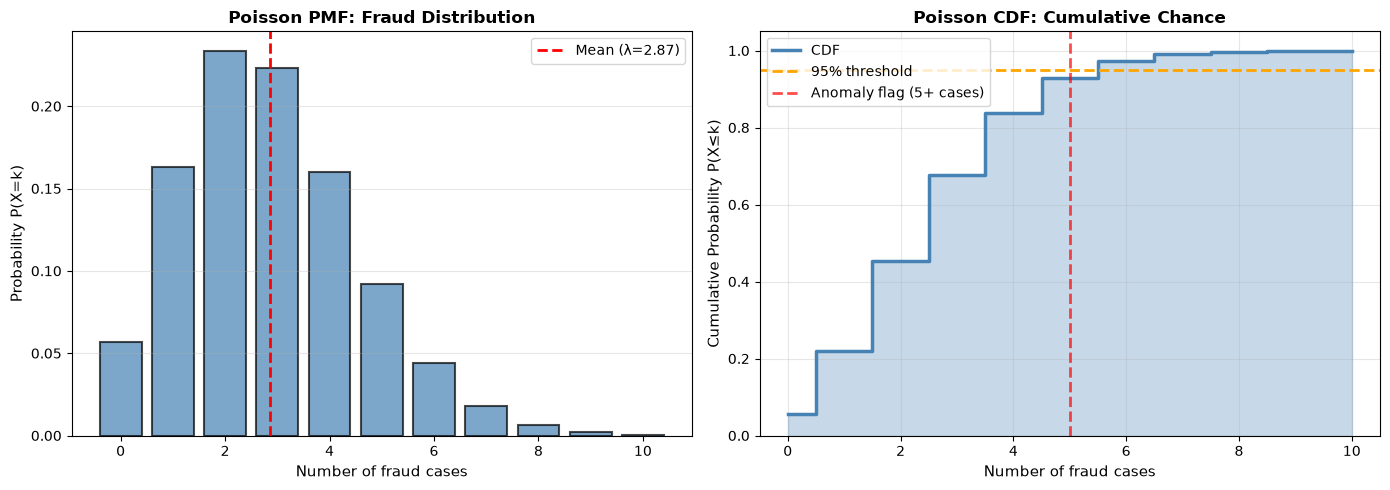

In [ ]:
# Problem: "How many fraud cases expected per week ?"
# Historical fraud data (simulated)
fraud_per_day = [2, 3, 1, 4, 2, 3, 5, 2, 3, 2, 4, 3, 2, 4, 3]  # 15 days

print("Historical fraud cases per day:")
print(fraud_per_day)
print(f"\nAverage (λ): {np.mean(fraud_per_day):.2f} cases/day")
print(f"Variance: {np.var(fraud_per_day):.2f}")

# Step 3: Fit Poisson Distribution to fraud data
λ = np.mean(fraud_per_day)  # Estimate λ from historical data

print(f"Estimated λ (average fraud cases/day): {λ:.2f}")
print(f"Variance in data: {np.var(fraud_per_day):.2f}")
print(f"Ratio (Var/Mean): {np.var(fraud_per_day)/λ:.2f} (Poisson signature ≈ 1.0)\n")

# Generate Poisson PMF for x = 0 to 10
x = np.arange(0, 11)
pmf = stats.poisson.pmf(x, λ)

# Print probability table
print("Poisson Probability Table:")
print("-" * 40)
print(f"{'Cases (k)':<12} {'P(X=k)':<15} {'P(X≤k)':<15}")
print("-" * 40)
cdf = stats.poisson.cdf(x, λ)
for i, (prob, cumprob) in enumerate(zip(pmf, cdf)):
    print(f"{i:<12} {prob:<15.4f} {cumprob:<15.4f}")
print("-" * 40)

# Step 4: Visualize Poisson Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PMF (Probability Mass Function)
ax1 = axes[0]
ax1.bar(x, pmf, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.axvline(λ, color='red', linestyle='--', linewidth=2, label=f'Mean (λ={λ:.2f})')
ax1.set_xlabel('Number of fraud cases', fontsize=11)
ax1.set_ylabel('Probability P(X=k)', fontsize=11)
ax1.set_title('Poisson PMF: Fraud Distribution', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.legend(fontsize=10)

# Plot 2: CDF (Cumulative Distribution Function)
ax2 = axes[1]
ax2.step(x, cdf, where='mid', color='steelblue', linewidth=2.5, label='CDF')
ax2.fill_between(x, 0, cdf, step='mid', alpha=0.3, color='steelblue')
ax2.axhline(0.95, color='orange', linestyle='--', linewidth=2, label='95% threshold')
ax2.axvline(5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Anomaly flag (5+ cases)')
ax2.set_xlabel('Number of fraud cases', fontsize=11)
ax2.set_ylabel('Cumulative Probability P(X≤k)', fontsize=11)
ax2.set_title('Poisson CDF: Cumulative Chance', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

**2. Exponential (Continuous)** . Time until next event. Formula: f(t) = λ × e^(-λt)  (PDF) Probability density at time t, Integral of PDF: Area under curve = 1, Use CDF for probability: P(T ≤ t) = 1 - e^(-λt). Exponential:  "How long until next fraud?" → time

If frauds happen at rate λ = 2.87 per day, what's the average time between frauds? Answer: 1/λ = 1/2.87 ≈ 0.35 days ≈ 8.4 hours

This is a crucial connection: Poisson (count): "3 frauds per day", Exponential (time):   "1 fraud every 0.35 days"

If frauds arrive at rate λ = 2.87/day, then time between them: T ~ Exponential(λ = 2.87) E[T] = 1/λ = 1/2.87 ≈ 0.35 days ≈ 8.4 hours

PDF tells you: Formula: f(t) = λ × e^(-λt)  
1. WHERE probability is concentrated (right at t=0 for exponential)
2. Probability density is highest at t=0
3. Density decreases exponentially over time
4. Does NOT mean fraud becomes less likely (use CDF for probability)

Example:
1. f(0) = 2.87 × e^0 = 2.87  (highest density right now)
2. f(0.35) = 2.87 × e^(-1) = 1.05  (lower instantaneous density at 8 hours)
3. f(1) = 2.87 × e^(-2.87) = 0.27  (much lower after 1 day)

The density of probability is decreasing over time, which is why the curve slopes downward.

As time passes, the instant probability of fraud RIGHT NOW decreases, because most frauds have already happened by then."The probability of waiting all the way to t=1 day is lower than waiting to t=0 (which already happened).

CDF: "By time t, HAS fraud happened?"
     → Increases as t increases (more certain YES)
     → At t=0.35: 63% sure fraud already happened

PDF: "IS fraud happening AT this moment (t)?"
     → Decreases as t increases
     → At t=0.35: lower density (less likely fraud is at exactly this moment)


**Key insight:** Exponential's PDF is highest at t=0, meaning fraud is most likely to happen RIGHT NOW, reflecting the 'memoryless' property." Each moment that passes without fraud, the probability of fraud in the NEXT instant remains the same rate λ.



QUESTION 2: How long until the next fraud?

Fraud rate: λ = 2.87 frauds/day
Expected time between frauds: 0.35 days
                            ≈ 8.4 hours

Probability of fraud within time t:
------------------------------------------------------------
Time            P(fraud within t)    P(no fraud for t)   
------------------------------------------------------------
0.5 days (12h) 0.7615 = 76.1%    0.2385 = 23.9%
1.0 days (24h) 0.9431 = 94.3%    0.0569 = 5.7%
2.0 days (48h) 0.9968 = 99.7%    0.0032 = 0.3%
7.0 days (168h) 1.0000 = 100.0%    0.0000 = 0.0%
------------------------------------------------------------


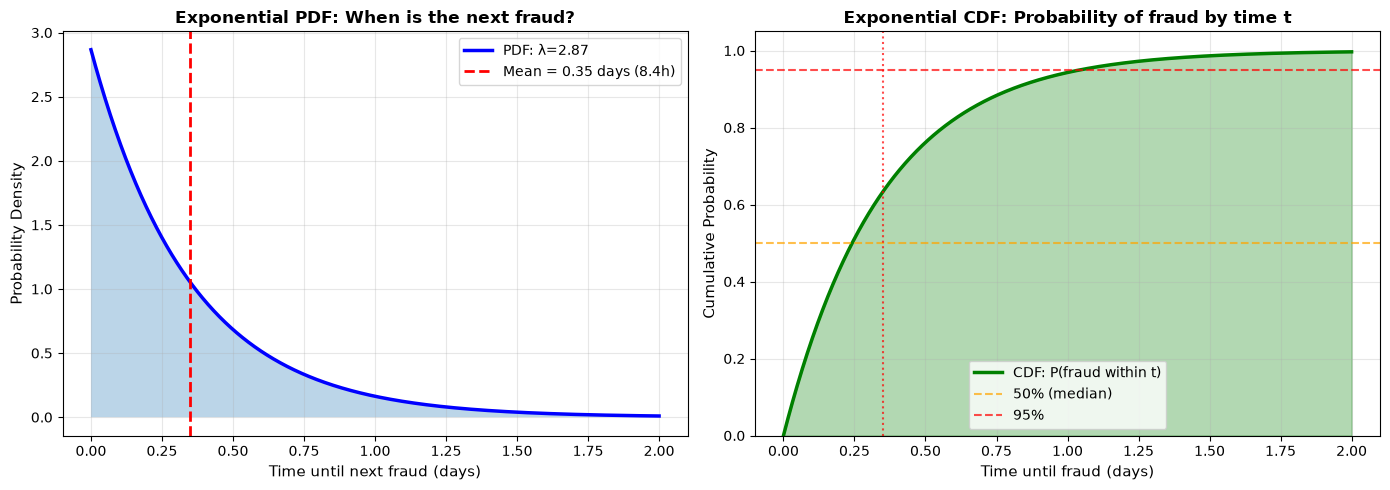


Key statistics:
  Mean waiting time: 0.349 days (8.4 hours)
  Median waiting time: 0.242 days (5.8 hours)


In [ ]:
# QUESTION 2: How long until the next fraud?
print("\n" + "="*70)
print("QUESTION 2: How long until the next fraud?")
print("="*70)

λ = np.mean(fraud_per_day)  # 2.87 frauds/day
E_time = 1 / λ  # Expected time in days

print(f"\nFraud rate: λ = {λ:.2f} frauds/day")
print(f"Expected time between frauds: {E_time:.2f} days")
print(f"                            ≈ {E_time*24:.1f} hours")

# Exponential CDF: P(T ≤ t) = 1 - e^(-λt)
# Time intervals to check (in days)
time_intervals = np.array([0.5, 1, 2, 7])  # 12 hrs, 24 hrs, 2 days, 1 week

print(f"\nProbability of fraud within time t:")
print("-" * 60)
print(f"{'Time':<15} {'P(fraud within t)':<20} {'P(no fraud for t)':<20}")
print("-" * 60)

for t in time_intervals:
    prob_fraud = 1 - np.exp(-λ * t)  # CDF
    prob_no_fraud = np.exp(-λ * t)    # Survival function
    hours = t * 24
    print(f"{t:.1f} days ({hours:.0f}h) {prob_fraud:.4f} = {prob_fraud*100:.1f}%    {prob_no_fraud:.4f} = {prob_no_fraud*100:.1f}%")

print("-" * 60)

# Visualize Exponential Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PDF (Probability Density Function)
t = np.linspace(0, 2, 1000)  # Time in days (0 to 2 days)
pdf = λ * np.exp(-λ * t)


ax1.plot(t, pdf, 'b-', linewidth=2.5, label=f'PDF: λ={λ:.2f}')
ax1.fill_between(t, pdf, alpha=0.3)
ax1.axvline(E_time, color='red', linestyle='--', linewidth=2, label=f'Mean = {E_time:.2f} days (8.4h)')
ax1.set_xlabel('Time until next fraud (days)', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title('Exponential PDF: When is the next fraud?', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend(fontsize=10)

# Plot 2: CDF (Cumulative Distribution)
cdf_exp = 1 - np.exp(-λ * t)
ax2.plot(t, cdf_exp, 'g-', linewidth=2.5, label='CDF: P(fraud within t)')
ax2.fill_between(t, 0, cdf_exp, alpha=0.3, color='green')
ax2.axhline(0.5, color='orange', linestyle='--', alpha=0.7, label='50% (median)')
ax2.axhline(0.95, color='red', linestyle='--', alpha=0.7, label='95%')
ax2.axvline(E_time, color='red', linestyle=':', alpha=0.7)
ax2.set_xlabel('Time until fraud (days)', fontsize=11)
ax2.set_ylabel('Cumulative Probability', fontsize=11)
ax2.set_title('Exponential CDF: Probability of fraud by time t', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# Median wait time
median_time = np.log(2) / λ  # log(2)/λ for exponential
print(f"\nKey statistics:")
print(f"  Mean waiting time: {E_time:.3f} days ({E_time*24:.1f} hours)")
print(f"  Median waiting time: {median_time:.3f} days ({median_time*24:.1f} hours)")

**3. Geometric Distribution** - A fraud detection system. It catches 80% of frauds. Question: On average, how many frauds occur before you detect one? This is Geometric Distribution. Geometric models: "Number of trials until first SUCCESS"

Your scenario:
  - Each fraud: either caught (success) or missed (failure)
  - Detection rate: p = 0.80 (80% success)
  - Question: How many frauds until first detection?

Geometric formula: P(X = k) = (1-p)^(k-1) × p, where k = number of frauds, p = detection rate. What it means: "Probability of catching fraud on the k-th attempt". Break it down: (1-p)^(k-1)  = probability of MISSING (k-1) times first, p = probability of catching on the k-th try

Example (p = 0.80):
  P(X=1) = (0.20)^0 × 0.80 = 0.80      (catch on 1st: 80%)
  P(X=2) = (0.20)^1 × 0.80 = 0.16      (miss 1st, catch 2nd: 16%)
  P(X=3) = (0.20)^2 × 0.80 = 0.032     (miss 2x, catch 3rd: 3.2%)
  P(X=4) = (0.20)^3 × 0.80 = 0.0064    (miss 3x, catch 4th: 0.64%)

Expected value:  E[X] = 1/p  , If p = 0.80, then E[X] = 1/0.8 = 1.25 frauds, On average, catch 1 fraud every 1.25 attempts

- E[X] = Σ k × P(X = k)  (definition of expectation)
     = Σ k × (1-p)^(k-1) × p
     = p × Σ k × (1-p)^(k-1)

- Let q = 1-p, then:
     = p × Σ k × q^(k-1)
     = p × [1 + 2q + 3q² + 4q³ + ...]

- Using geometric series formula: Σ k×q^(k-1) = 1/(1-q)²
     = p × 1/(1-q)²
     = p × 1/p²          (since 1-q = p)
     = 1/p

P(X > 3) = "Need more than 3 trials" = "Miss first 3, success comes later" = (0.20)^3 = 0.008 = 0.8% . Meaning: 0.8% chance you miss 3 frauds in a row P(X > k) only counts FAILURES in first k trials. The success comes AFTER trial k (whenever it is). So we don't multiply by p.
- P(X = k) = (1-p)^(k-1) × p  ← includes success on trial k
- P(X > k) = (1-p)^k          ← only failures in first k




QUESTION 3: How many frauds until detection?

Detection rate: p = 80.0%
Expected frauds until first catch: E[X] = 1/p = 1.25

Interpretation:
  On average, catch 1 fraud every 1.25 frauds
  Or equivalently: miss 20% of frauds

Geometric Distribution: Number of frauds until first detection
----------------------------------------------------------------------
Frauds (k)   P(X=k)          P(X≤k)          Interpretation           
----------------------------------------------------------------------
1            0.8000          0.8000          Catch on 1st             
2            0.1600          0.9600          Catch on 2nd             
3            0.0320          0.9920          99% detected by fraud #3 
4            0.0064          0.9984          100% detected by fraud #4
5            0.0013          0.9997          100% detected by fraud #5
6            0.0003          0.9999          100% detected by fraud #6
7            0.0001          1.0000          100% detected by fraud #7

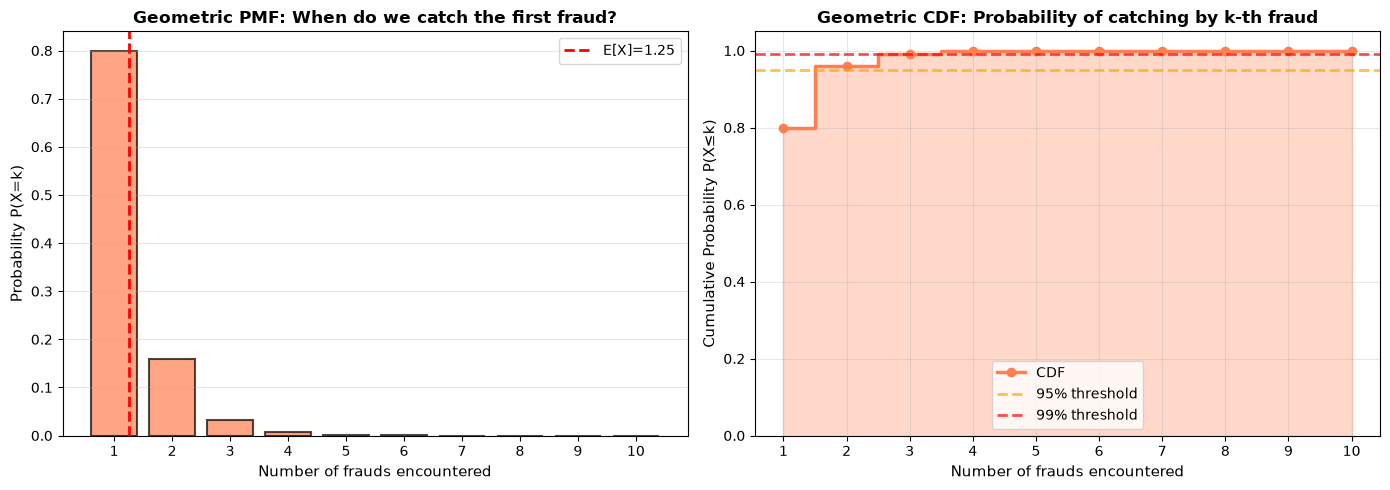


SUMMARY: Detection System Performance
Detection accuracy: 80%
Expected frauds/catch: 1.25
False negative rate: 20%

Risk profile:
  • 20% chance miss 1st fraud
  • 4% chance miss first 2 frauds
  • 0.8% chance miss first 3 frauds


In [26]:
# QUESTION 3: How many frauds until we catch one?
print("\n" + "="*70)
print("QUESTION 3: How many frauds until detection?")
print("="*70)

# Detection rate (your system catches 80% of frauds)
p_detect = 0.80

print(f"\nDetection rate: p = {p_detect:.1%}")
print(f"Expected frauds until first catch: E[X] = 1/p = {1/p_detect:.2f}")
print(f"\nInterpretation:")
print(f"  On average, catch 1 fraud every {1/p_detect:.2f} frauds")
print(f"  Or equivalently: miss {1-p_detect:.0%} of frauds\n")

# Geometric PMF
k = np.arange(1, 16)  # 1 to 15 frauds
pmf_geom = (1 - p_detect)**(k - 1) * p_detect

# Geometric CDF
# Direct approach: Sum PMF terms
#   P(X ≤ k) = P(X=1) + P(X=2) + ... + P(X=k)
#   = 0.80 + 0.16 + 0.032 + ... (tedious!)

# Complement approach: Much simpler
#   P(X ≤ k) = 1 - P(X > k)
#            = 1 - P(miss all k)
#            = 1 - (1-p)^k

# P(catch at least 1 within k) = 1 - P(miss all k)
# P(X ≤ k) = Probability of catching fraud within k attempts
cdf_geom = 1 - (1 - p_detect)**k

print("Geometric Distribution: Number of frauds until first detection")
print("-" * 70)
print(f"{'Frauds (k)':<12} {'P(X=k)':<15} {'P(X≤k)':<15} {'Interpretation':<25}")
print("-" * 70)

for i, (prob, cumprob) in enumerate(zip(pmf_geom[:10], cdf_geom[:10])):
    k_val = i + 1
    if k_val == 1:
        interp = "Catch on 1st"
    elif k_val == 2:
        interp = "Catch on 2nd"
    else:
        interp = f"{cumprob*100:.0f}% detected by fraud #{k_val}"
    print(f"{k_val:<12} {prob:<15.4f} {cumprob:<15.4f} {interp:<25}")

print("-" * 70)

# Key probabilities
print(f"\nKey insights:")
print(f"  P(catch on 1st fraud)   = {pmf_geom[0]:.1%}")
print(f"  P(catch within 2 frauds) = {cdf_geom[1]:.1%}")
print(f"  P(catch within 5 frauds) = {cdf_geom[4]:.1%}")
print(f"  P(miss 3+ frauds in a row) = {(1-p_detect)**3:.1%}")

# Visualize Geometric Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PMF (Probability of catching on exactly k-th fraud)
k_plot = np.arange(1, 11)
pmf_plot = (1 - p_detect)**(k_plot - 1) * p_detect

ax1.bar(k_plot, pmf_plot, color='coral', alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.axvline(1/p_detect, color='red', linestyle='--', linewidth=2, label=f'E[X]={1/p_detect:.2f}')
ax1.set_xlabel('Number of frauds encountered', fontsize=11)
ax1.set_ylabel('Probability P(X=k)', fontsize=11)
ax1.set_title('Geometric PMF: When do we catch the first fraud?', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_xticks(k_plot)

# Plot 2: CDF (Probability of catching within k frauds)
cdf_plot = 1 - (1 - p_detect)**k_plot

ax2.step(k_plot, cdf_plot, where='mid', color='coral', linewidth=2.5, marker='o', markersize=6, label='CDF')
ax2.fill_between(k_plot, 0, cdf_plot, step='mid', alpha=0.3, color='coral')
ax2.axhline(0.95, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='95% threshold')
ax2.axhline(0.99, color='red', linestyle='--', linewidth=2, alpha=0.7, label='99% threshold')
ax2.set_xlabel('Number of frauds encountered', fontsize=11)
ax2.set_ylabel('Cumulative Probability P(X≤k)', fontsize=11)
ax2.set_title('Geometric CDF: Probability of catching by k-th fraud', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_xticks(k_plot)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("SUMMARY: Detection System Performance")
print("="*70)
print(f"Detection accuracy: {p_detect:.0%}")
print(f"Expected frauds/catch: {1/p_detect:.2f}")
print(f"False negative rate: {1-p_detect:.0%}")
print(f"\nRisk profile:")
print(f"  • 20% chance miss 1st fraud")
print(f"  • 4% chance miss first 2 frauds")
print(f"  • 0.8% chance miss first 3 frauds")
print("="*70)
